In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

In [9]:
df = pd.read_csv("supershops.csv")
df.head()

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.10,Dhaka,192261.83
1,162597.70,151377.59,443898.53,Ctg,191792.06
2,153441.51,101145.55,407934.54,Rangpur,191050.39
3,144372.41,118671.85,383199.62,Dhaka,182901.99
4,142107.34,91391.77,366168.42,Rangpur,166187.94


In [10]:
df.tail()

,Marketing Spend,Administration,Transport,Area,Profit
45,1000.23,124153.04,1903.93,Dhaka,64926.08
46,1315.46,115816.21,297114.46,Rangpur,49490.75
47,0.00,135426.92,0.00,Ctg,42559.73
48,542.05,51743.15,0.00,Dhaka,35673.41
49,0.00,116983.80,45173.06,Ctg,14681.40


In [3]:
df.shape

(50, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Marketing Spend  50 non-null     float64
 1   Administration   50 non-null     float64
 2   Transport        49 non-null     float64
 3   Area             50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [7]:
df.describe()

,Marketing Spend,Administration,Transport,Profit
count,50.000000,50.000000,49.000000,50.000000
mean,73721.615600,121344.639600,215331.732449,112012.639200
std,45902.256482,28017.802755,119665.391550,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,134050.070000,90138.902500
50%,73051.080000,122699.795000,214634.810000,107978.190000
75%,101602.800000,144842.180000,299737.290000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [8]:
df.isna().sum()

Marketing Spend    0
Administration     0
Transport          1
Area               0
Profit             0
dtype: int64

In [11]:
# Visualization

In [12]:
df.head()

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.10,Dhaka,192261.83
1,162597.70,151377.59,443898.53,Ctg,191792.06
2,153441.51,101145.55,407934.54,Rangpur,191050.39
3,144372.41,118671.85,383199.62,Dhaka,182901.99
4,142107.34,91391.77,366168.42,Rangpur,166187.94


In [13]:
df['Area'].value_counts()

Area
Dhaka      17
Ctg        17
Rangpur    16
Name: count, dtype: int64

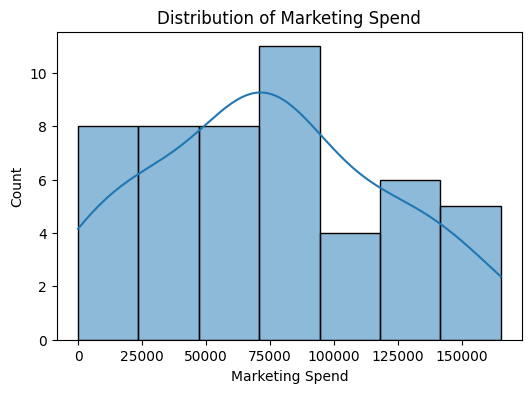

In [19]:
plt.figure(figsize=(6,4))
sns.histplot(df['Marketing Spend'], kde=True)
plt.title("Distribution of Marketing Spend")
plt.show()


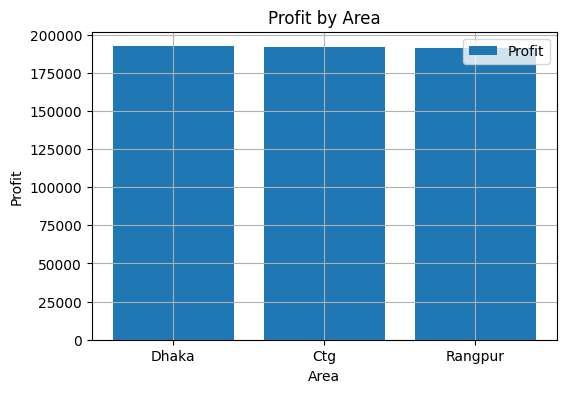

In [22]:
plt.figure(figsize=(6,4))
plt.bar(df['Area'], df['Profit'], label='Profit')
plt.xlabel("Area")
plt.ylabel("Profit")
plt.title("Profit by Area")
plt.legend()
plt.grid()
plt.show()


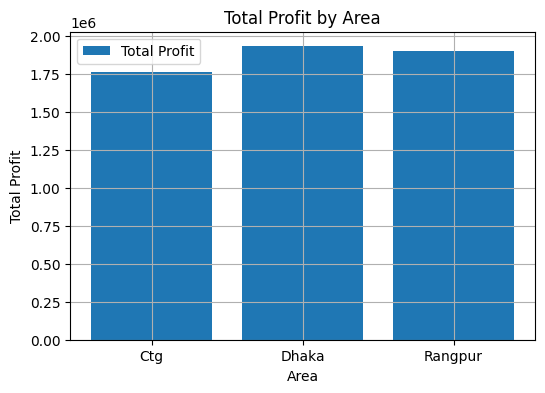

In [29]:
area_profit = df.groupby('Area')['Profit'].sum()

plt.figure(figsize=(6,4))
plt.bar( area_profit.index, area_profit.values, label='Total Profit')
plt.xlabel("Area")
plt.ylabel("Total Profit")
plt.title("Total Profit by Area")
plt.legend()
plt.grid()
plt.show()


# Feature Transformation

## MinMax Scaling

In [30]:
df1 = df.copy()
df2 = df.copy()
df3 = df.copy()
df4 = df.copy()
df5 = df.copy()
df6 = df.copy()

In [31]:
df1.head()

,Marketing Spend,Administration,Transport,Area,Profit
0,114523.61,136897.80,471784.10,Dhaka,192261.83
1,162597.70,151377.59,443898.53,Ctg,191792.06
2,153441.51,101145.55,407934.54,Rangpur,191050.39
3,144372.41,118671.85,383199.62,Dhaka,182901.99
4,142107.34,91391.77,366168.42,Rangpur,166187.94


In [33]:
mms = MinMaxScaler(feature_range=(0,1))
mms

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [40]:
x = df1.iloc[:, 0:4] # Selecting columns to apply Normalization - MinMaxScaling
y = df1[['Profit']]


In [39]:
print(x.head())
print()
print(y.head())

   Marketing Spend  Administration  Transport     Area
0        114523.61       136897.80  471784.10    Dhaka
1        162597.70       151377.59  443898.53      Ctg
2        153441.51       101145.55  407934.54  Rangpur
3        144372.41       118671.85  383199.62    Dhaka
4        142107.34        91391.77  366168.42  Rangpur

      Profit
0  192261.83
1  191792.06
2  191050.39
3  182901.99
4  166187.94


In [41]:
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Marketing Spend  50 non-null     float64
 1   Administration   50 non-null     float64
 2   Transport        49 non-null     float64
 3   Area             50 non-null     object 
dtypes: float64(3), object(1)
memory usage: 1.7+ KB


In [42]:
x.columns

Index(['Marketing Spend', 'Administration', 'Transport', 'Area'], dtype='object')

In [43]:
for col in x.columns:
    if x[col].dtypes == "object":
        continue
    x[col] = mms.fit_transform(x[[col]])
x.head()    

,Marketing Spend,Administration,Transport,Area
0,0.692617,0.651744,1.000000,Dhaka
1,0.983359,0.761972,0.940893,Ctg
2,0.927985,0.379579,0.864664,Rangpur
3,0.873136,0.512998,0.812235,Dhaka
4,0.859438,0.305328,0.776136,Rangpur
